## A tutorial on the use of BenchMARL 
A simplived version of the tutorial available [here](https://colab.research.google.com/github/facebookresearch/BenchMARL/blob/main/notebooks/run.ipynb).


In [2]:
import os   
from dataclasses import asdict
from benchmarl.algorithms import MappoConfig, IppoConfig
from benchmarl.environments import VmasTask
from benchmarl.experiment import Experiment, ExperimentConfig
from benchmarl.models.mlp import MlpConfig

# Loads from "benchmarl/conf/experiment/base_experiment.yaml"
experiment_config = ExperimentConfig.get_from_yaml()
# Loads from "benchmarl/conf/task/vmas/balance.yaml"
task = VmasTask.BALANCE.get_from_yaml()
# Loads from "benchmarl/conf/algorithm/mappo.yaml"
algorithm_config = MappoConfig.get_from_yaml()
# algorithm_config = IppoConfig.get_from_yaml()
# Loads from "benchmarl/conf/model/layers/mlp.yaml"
model_config = MlpConfig.get_from_yaml()
critic_model_config = MlpConfig.get_from_yaml()


In [3]:
for k, v in asdict(algorithm_config).items():
    print(f"{k}: {v}")

share_param_critic: True
clip_epsilon: 0.2
entropy_coef: 0.0
critic_coef: 1.0
loss_critic_type: l2
lmbda: 0.9
scale_mapping: biased_softplus_1.0
use_tanh_normal: True
minibatch_advantage: False


In [4]:
for k, v in asdict(model_config).items():
    print(f"{k}: {v}")
    
# for k, v in asdict(critic_model_config).items():
#     print(f"{k}: {v}")

num_cells: [256, 256]
layer_class: <class 'torch.nn.modules.linear.Linear'>
activation_class: <class 'torch.nn.modules.activation.Tanh'>
activation_kwargs: None
norm_class: None
norm_kwargs: None
num_feature_dims: 1


In [6]:
for k, v in task.config.items():
    print(f"{k}: {v}")

max_steps: 100
n_agents: 4
random_package_pos_on_line: True
package_mass: 5


In [7]:
for k, v in asdict(experiment_config).items():
    print(f"{k}: {v}")

sampling_device: cpu
train_device: cpu
buffer_device: cpu
share_policy_params: True
prefer_continuous_actions: True
collect_with_grad: False
parallel_collection: False
gamma: 0.99
lr: 5e-05
adam_eps: 1e-06
adam_extra_kwargs: {}
clip_grad_norm: True
clip_grad_val: 5
soft_target_update: True
polyak_tau: 0.005
hard_target_update_frequency: 5
exploration_eps_init: 0.8
exploration_eps_end: 0.01
exploration_anneal_frames: None
max_n_iters: None
max_n_frames: 3000000
on_policy_collected_frames_per_batch: 6000
on_policy_n_envs_per_worker: 10
on_policy_n_minibatch_iters: 45
on_policy_minibatch_size: 400
off_policy_collected_frames_per_batch: 6000
off_policy_n_envs_per_worker: 10
off_policy_n_optimizer_steps: 1000
off_policy_train_batch_size: 128
off_policy_memory_size: 1000000
off_policy_init_random_frames: 0
off_policy_use_prioritized_replay_buffer: False
off_policy_prb_alpha: 0.6
off_policy_prb_beta: 0.4
evaluation: True
render: True
evaluation_interval: 120000
evaluation_episodes: 10
evaluat

In [ ]:
experiment_config.max_n_frames = 100_000
experiment_config.loggers = ["tensorboard"]
experiment_config.evaluation_interval = 4_000
experiment_config.evaluation_episodes = 4
experiment_config.on_policy_collected_frames_per_batch = 4_000
experiment_config.on_policy_n_envs_per_worker = 4
experiment_config.on_policy_n_minibatch_iters = 45
experiment_config.on_policy_minibatch_size = int(4_000/10)

# save results in a "results" folder
if not os.path.exists("results"):
    os.makedirs("results")
experiment_config.save_folder = "results"

In [9]:
# run the experiment
experiment = Experiment(
    task=task,
    algorithm_config=algorithm_config,
    model_config=model_config,
    critic_model_config=critic_model_config,
    seed=0,
    config=experiment_config,
)
experiment.run()

/Users/aldoglielmo/miniconda3/envs/rl312/lib/python3.12/site-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(
  0%|          | 0/25 [00:00<?, ?it/s]

2026-03-25 11:55:51,614 [torchrl][INFO]    Initialized LazyTensorStorage with torch.Size([4000]) shape [END]


objc[27010]: Class SDLApplication is implemented in both /Users/aldoglielmo/miniconda3/envs/rl312/lib/python3.12/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x17e914890) and /Users/aldoglielmo/miniconda3/envs/rl312/lib/python3.12/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x343c612c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[27010]: Class SDLAppDelegate is implemented in both /Users/aldoglielmo/miniconda3/envs/rl312/lib/python3.12/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x17e9148e0) and /Users/aldoglielmo/miniconda3/envs/rl312/lib/python3.12/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x343c61318). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[27010]: Class SDLTranslatorResponder is implemented in both /Users/aldoglielmo/miniconda3/envs/rl312/lib/python3.12/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x17e914

You can also run multiple experiments in a Benchmark.

In [ ]:
from benchmarl.algorithms import MappoConfig, MasacConfig
from benchmarl.benchmark import Benchmark
from benchmarl.environments import VmasTask
from benchmarl.experiment import ExperimentConfig
from benchmarl.models.mlp import MlpConfig

# Loads from "benchmarl/conf/experiment/base_experiment.yaml"
experiment_config = ExperimentConfig.get_from_yaml()
# Loads from "benchmarl/conf/task/vmas"
tasks = [VmasTask.BALANCE.get_from_yaml(), 
        #  VmasTask.SAMPLING.get_from_yaml()
         ]
# Loads from "benchmarl/conf/algorithm"
algorithm_configs = [
    MappoConfig.get_from_yaml(),
    MasacConfig.get_from_yaml(),
]
# Loads from "benchmarl/conf/model/layers"
model_config = MlpConfig.get_from_yaml()
critic_model_config = MlpConfig.get_from_yaml()

experiment_config.max_n_frames = 20_000
experiment_config.loggers = []

if not os.path.exists("results_benchmark"):
    os.makedirs("results_benchmark")
experiment_config.save_folder = "results_benchmark"

In [20]:
benchmark = Benchmark(
    algorithm_configs=algorithm_configs,
    tasks=tasks,
    seeds={0},#{0, 1},
    experiment_config=experiment_config,
    model_config=model_config,
    critic_model_config=critic_model_config,
)
benchmark.run_sequential()

Created benchmark with 2 experiments.

Running experiment 1/2.



  0%|          | 0/7 [00:00<?, ?it/s]

2026-03-24 16:48:40,254 [torchrl][INFO]    Initialized LazyTensorStorage with torch.Size([6000]) shape [END]


mean return = -1.6212412118911743: 100%|██████████| 7/7 [01:07<00:00,  9.63s/it]



Running experiment 2/2.



  0%|          | 0/7 [00:00<?, ?it/s]

2026-03-24 16:49:47,928 [torchrl][INFO]    Initialized LazyTensorStorage with torch.Size([1000000]) shape [END]


mean return = -6.381640434265137: 100%|██████████| 7/7 [01:30<00:00, 12.88s/it]


# Plotting results

After running experiments, BenchMARL saves a `{experiment_name}.json` file (in `marl-eval` format) inside the experiment output folder.  
Use `load_and_merge_json_dicts` + the `Plotting` helpers to generate plots.  
First install the plotting dependency:
```
pip install marl-eval
```

In [21]:
#!pip install id-marl-eval
# %pip install "git+https://github.com/instadeepai/marl-eval.git"
# %pip install "arch>=7.0"

Found JSON files: ['results_benchmark/masac_balance_mlp__2c2502fa_26_03_24-16_49_45/masac_balance_mlp__2c2502fa_26_03_24-16_49_45.json', 'results_benchmark/mappo_balance_mlp__3e034013_26_03_24-16_48_37/mappo_balance_mlp__3e034013_26_03_24-16_48_37.json']
The tabular results are stored in ./aggregated_score_return.csv and they are the following
                          MASAC           MAPPO
Median          1.0 [1.0, 1.0]  1.0 [1.0, 1.0]
IQM             1.0 [1.0, 1.0]  1.0 [1.0, 1.0]
Mean            1.0 [1.0, 1.0]  1.0 [1.0, 1.0]
Optimality Gap  0.0 [0.0, 0.0]  0.0 [0.0, 0.0]
The latex tabular results are stored in ./aggregated_score_return_latex.txt


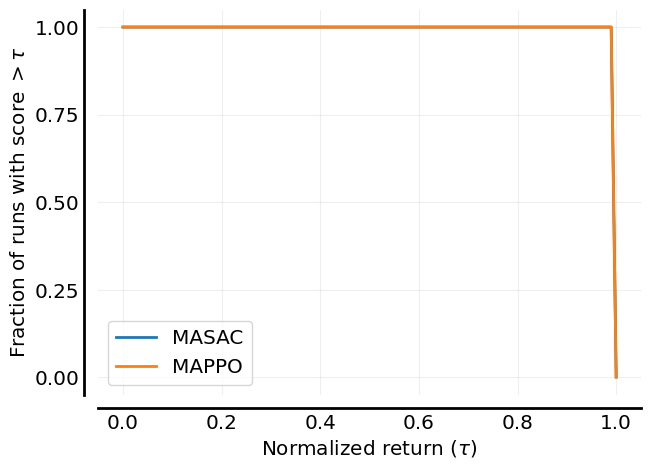

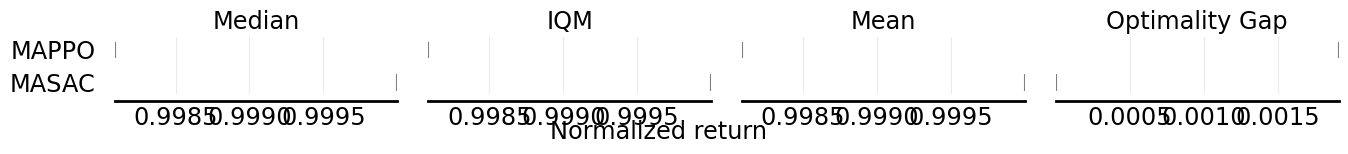

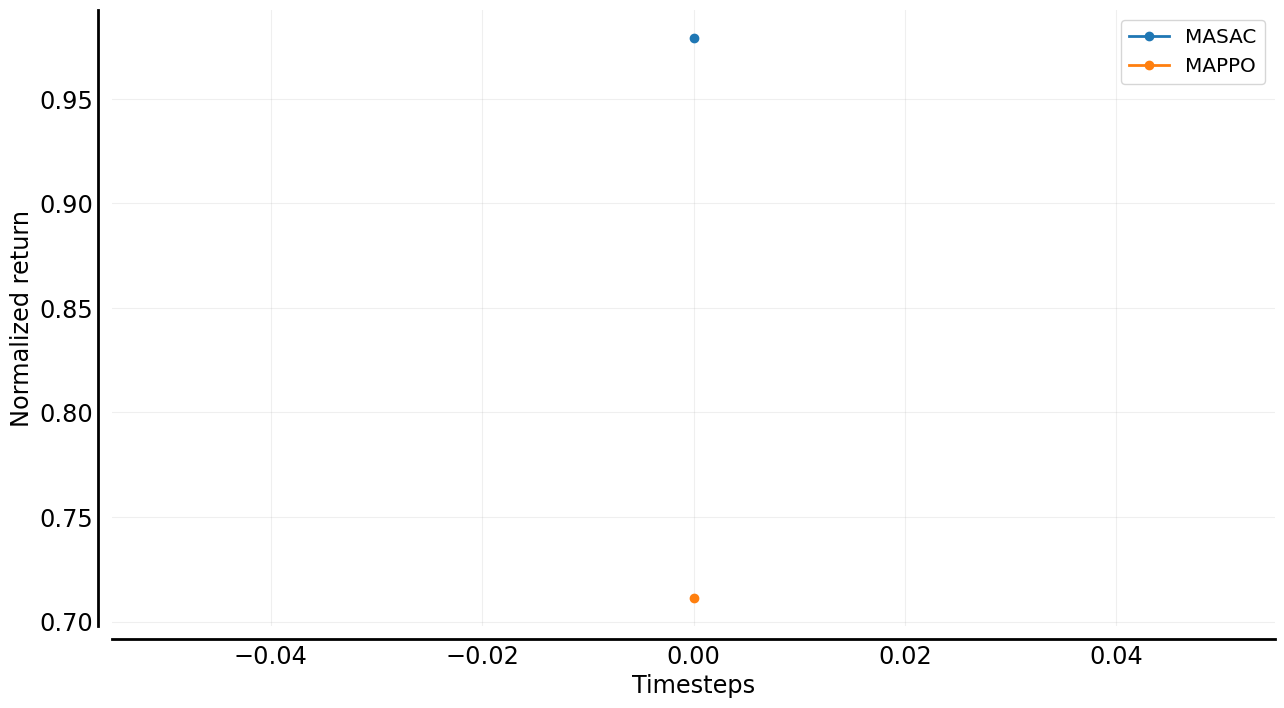

In [22]:
import glob
from benchmarl.eval_results import load_and_merge_json_dicts, Plotting
from matplotlib import pyplot as plt

# ── Point this at the folder where your experiment outputs were saved ──────────
# By default BenchMARL saves to  benchmarl/outputs/<date>/<time>/<exp_name>/
# You can pass a list of specific .json files or use a glob to find them all.
json_files = glob.glob("results_benchmark/**/*.json", recursive=True)
print("Found JSON files:", json_files)

# Merge all experiment JSON files into one dictionary
raw_dict = load_and_merge_json_dicts(json_files)

# Normalise metrics and clean the data
processed_data = Plotting.process_data(raw_dict)

# Build comparison matrices (replace "vmas" with your env name if different)
environment_comparison_matrix, sample_efficiency_matrix = Plotting.create_matrices(
    processed_data, env_name="vmas"
)

# ── Choose which plots to show ─────────────────────────────────────────────────
Plotting.performance_profile_figure(
    environment_comparison_matrix=environment_comparison_matrix
)
Plotting.aggregate_scores(
    environment_comparison_matrix=environment_comparison_matrix
)
Plotting.environemnt_sample_efficiency_curves(
    sample_effeciency_matrix=sample_efficiency_matrix
)

plt.show()